# Team 04 Agent Graph Visualization
This notebook compiles the current `team_04/agent/graph.py` LangGraph workflow and renders it as Mermaid text plus a Mermaid PNG.

It uses the local tool client only, so you can inspect the graph topology without connecting to MCP services or running the full agent.

In [ ]:
from pathlib import Path
import sys

from IPython.display import Image, Markdown, display

workspace_root = Path.cwd().resolve()
candidate_roots = (
    workspace_root,
    workspace_root.parent,
    workspace_root / 'team_04',
    workspace_root.parent / 'team_04',
)
team_root = next((path for path in candidate_roots if (path / 'agent').exists()), None)

if team_root is None:
    raise FileNotFoundError('Run this notebook from the workspace root, the team_04 folder, or the team_04/notebooks folder.')

team_root_str = str(team_root)
if team_root_str not in sys.path:
    sys.path.insert(0, team_root_str)

from agent.decision_engine import RuleBasedPlanner
from agent.graph import build_agent_graph
from agent.mcp_client import build_default_local_tool_client
from agent.models import RoutingDecision
from agent.tool_catalog import ToolCatalog

c:\Users\Admin\.conda\envs\311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Admin\.conda\envs\311\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class StubDecisionEngine:
    def decide(self, state, catalog, active_step):
        return RoutingDecision(action=active_step.action, reasoning=active_step.goal)

    def build_report(self, state):
        return 'Graph visualization only.'

tool_client = build_default_local_tool_client()
catalog = ToolCatalog.from_discovered_tools(tool_client.list_tools())
app = build_agent_graph(
    decision_engine=StubDecisionEngine(),
    tool_client=tool_client,
    catalog=catalog,
    planner=RuleBasedPlanner(),
)
graph_view = app.get_graph()
mermaid_text = graph_view.draw_mermaid()
display(Markdown('## Mermaid Definition'))
print(mermaid_text)

## Mermaid Definition

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	central_reason(central_reason)
	read_site(read_site)
	generate_shape(generate_shape)
	check_requested_position(check_requested_position)
	check_constraints(check_constraints)
	optimize(optimize)
	evaluate(evaluate)
	place_building(place_building)
	analyze_remaining_positions(analyze_remaining_positions)
	await_human(await_human)
	report(report)
	finish(finish)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	analyze_remaining_positions --> planner;
	await_human --> finish;
	central_reason -.-> analyze_remaining_positions;
	central_reason -.-> await_human;
	central_reason -.-> check_constraints;
	central_reason -.-> check_requested_position;
	central_reason -.-> evaluate;
	central_reason -.-> finish;
	central_reason -.-> generate_shape;
	central_reason -.-> optimize;
	central_reason -.-> place_building;
	central_reason -.-> read_site;
	central_reason -.-> report;


## Mermaid PNG
Saved to `c:\Users\Admin\Documents\GitHub\AIA26_Studio\team_04\agent_graph_mermaid.png`

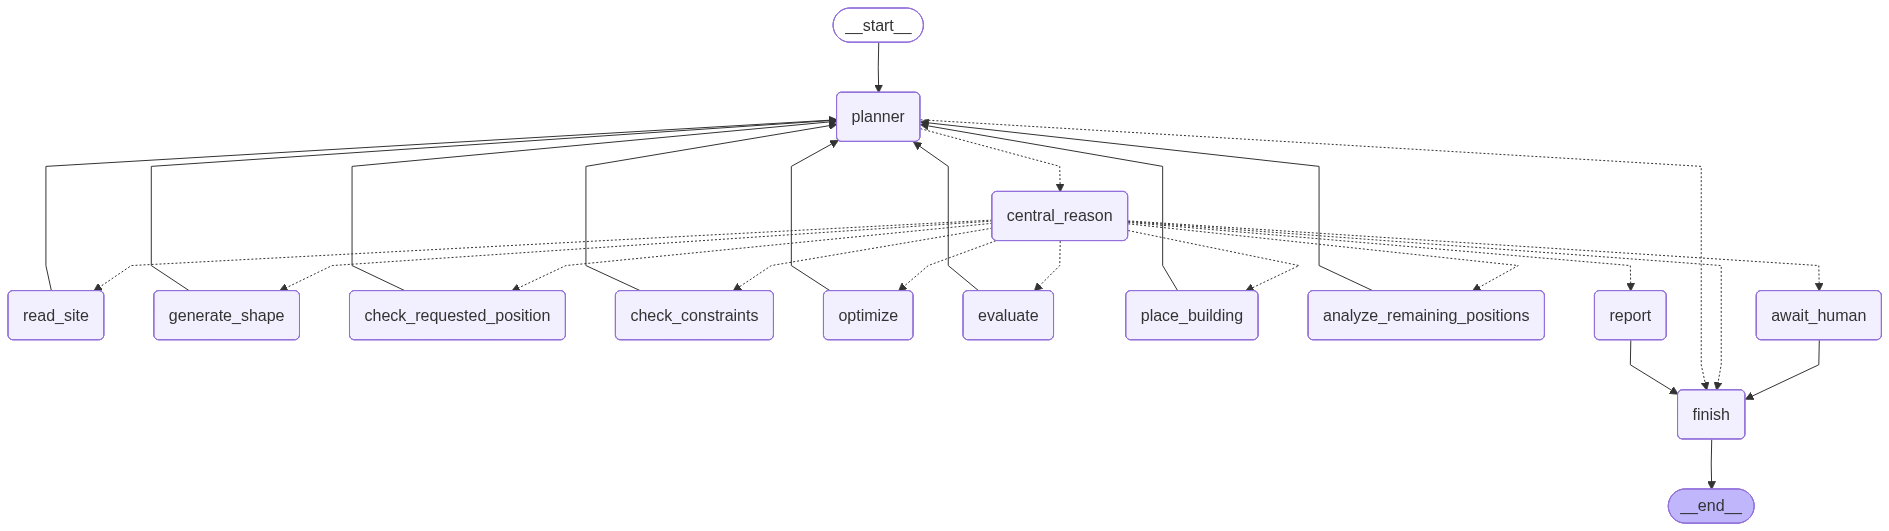

In [ ]:
png_bytes = graph_view.draw_mermaid_png()
output_path = team_root / 'notebooks' / 'agent_graph_mermaid.png'
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_bytes(png_bytes)
display(Markdown(f'## Mermaid PNG\nSaved to `{output_path}`'))
display(Image(data=png_bytes))
tool_client.close()